# Notebook 1 — DXY Data Exploration

**Bachelor thesis:** Testing Market Efficiency: Evidence from the US Dollar Index and Emerging Markets

---

**Run order:** this is the first DXY notebook. Run it before Notebook 2 and Notebook 3.

**This notebook:**
1. Downloads and cleans DXY price data and 9 cross-asset instruments.
2. Computes log returns and descriptive statistics.
3. Runs stationarity, autocorrelation, heteroskedasticity, and normality diagnostics.
4. Explores cross-asset correlations.
5. Builds and saves the processed dataset used by the DXY modelling notebooks.
6. Generates DXY exploratory thesis figures.

**Output:** `data/processed/dxy_dataset_features.csv` and `dxy_dataset_target.csv` — used in notebooks 02 and 03.


Library imports and environment setup. Plot style set to seaborn-whitegrid, default figure size 14×8.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import yfinance

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 14

import sys
import importlib
from pathlib import Path

_cwd = Path.cwd().resolve()
if _cwd.name == "notebooks":
    _dxy_root = _cwd.parent
elif (_cwd / "config.py").is_file():
    _dxy_root = _cwd
elif (_cwd / "DXY_part" / "config.py").is_file():
    _dxy_root = _cwd / "DXY_part"
else:
    _dxy_root = _cwd.parent
sys.path.insert(0, str(_dxy_root))

import config as _dxy_config_module
importlib.reload(_dxy_config_module)
config = _dxy_config_module.config

from src.data.loader import DataLoader
from src.data.processor import DataProcessor
from src.analysis.exploratory import TimeSeriesAnalyzer
from src.analysis.statistical_tests import StatisticalTests, print_test_result

print("All imports successful!")


All imports successful!


## 1. Load Data


In [2]:
loader = DataLoader()

dxy = loader.fetch_dxy(start_date='2005-01-01')

print(f"DXY data shape: {dxy.shape}")
print(f"Date range: {dxy.index.min().date()} to {dxy.index.max().date()}")
print(f"Columns: {list(dxy.columns)}")
dxy.head()


DXY data shape: (5349, 5)
Date range: 2005-01-03 to 2026-03-30
Columns: [('Close', 'DX-Y.NYB'), ('High', 'DX-Y.NYB'), ('Low', 'DX-Y.NYB'), ('Open', 'DX-Y.NYB'), ('Volume', 'DX-Y.NYB')]


Price,Close,High,Low,Open,Volume
Ticker,DX-Y.NYB,DX-Y.NYB,DX-Y.NYB,DX-Y.NYB,DX-Y.NYB
Date,,,,,
2005-01-03,81.300003,81.760002,80.769997,81.050003,0
2005-01-04,82.570000,82.709999,81.180000,81.360001,0
2005-01-05,82.540001,82.919998,82.300003,82.489998,0
2005-01-06,83.150002,83.230003,82.430000,82.449997,0
2005-01-07,83.610001,83.790001,82.610001,83.070000,0


Download daily OHLCV data for DXY (US Dollar Index ETF) from Yahoo Finance starting January 2005.

In [3]:
features = loader.fetch_yahoo_data(config.data.feature_tickers)

print(f"Features shape: {features.shape}")
print(f"Columns: {features.columns.tolist()}")
features.head()

Features shape: (5537, 9)
Columns: ['CAD=X', 'CL=F', 'EEM', 'EURUSD=X', 'GBPUSD=X', 'GC=F', 'HG=F', '^GSPC', '^TNX']


Ticker,CAD=X,CL=F,EEM,EURUSD=X,GBPUSD=X,GC=F,HG=F,^GSPC,^TNX
Date,,,,,,,,,
2005-01-03,1.2078,42.119999,14.562678,1.347001,1.904617,428.700012,1.5235,1202.079956,4.220
2005-01-04,1.2212,43.910000,14.114312,1.328198,1.883594,428.500000,1.3950,1188.050049,4.283
2005-01-05,1.2244,43.389999,13.941528,1.328004,1.885512,426.600006,1.4220,1183.739990,4.277
2005-01-06,1.2353,45.560001,13.932054,1.318305,1.876490,421.000000,1.4200,1187.890015,4.272
2005-01-07,1.2313,45.430000,13.959024,1.306097,1.871293,418.899994,1.4150,1186.189941,4.285


Download daily closing prices for 9 cross-asset instruments from Yahoo Finance: DXY, VIX, 10Y Treasury, Oil (WTI), Copper, Gold, S&P 500, CNY, JPY.

## 2. Data Preprocessing


In [4]:
processor = DataProcessor()

dxy_clean = processor.clean_data(dxy)
features_clean = processor.clean_data(features)

dxy_returns = processor.calculate_returns(dxy_clean[['Close']], method='log')
dxy_returns.columns = ['DXY_return']

print(f"Cleaned DXY: {len(dxy_clean)} records")
print(f"DXY returns: {len(dxy_returns)} observations")
print(f"\nDescriptive statistics:")
print(dxy_returns.describe())

Cleaned DXY: 5349 records
DXY returns: 5348 observations

Descriptive statistics:
        DXY_return
count  5348.000000
mean      0.000040
std       0.004756
min      -0.027169
25%      -0.002631
50%       0.000000
75%       0.002723
max       0.025237


## 3. Statistical Tests


Five tests on DXY log returns: ADF and KPSS (stationarity), Ljung-Box (autocorrelation), ARCH-LM (heteroskedasticity), Jarque-Bera (normality).

In [5]:
tests = StatisticalTests()

print("\n" + "="*60)
print("  STATISTICAL TESTS: DXY RETURNS")
print("="*60)

results = tests.run_all_tests(dxy_returns['DXY_return'], 'DXY Returns')

for name, result in results.items():
    print_test_result(result)


  STATISTICAL TESTS: DXY RETURNS

  Augmented Dickey-Fuller Test
  Test Statistic: -22.044241
  P-Value: 0.000000
  Critical Values:
    1%: -3.4316
    5%: -2.8621
    10%: -2.5671

  ➤ Conclusion: STATIONARY (p=0.0000 < 0.05)

  KPSS Test
  Test Statistic: 0.041643
  P-Value: 0.100000
  Critical Values:
    10%: 0.3470
    5%: 0.4630
    2.5%: 0.5740
    1%: 0.7390

  ➤ Conclusion: STATIONARY (p=0.1000 >= 0.05)

  Ljung-Box Test
  Test Statistic: 22.195024
  P-Value: 0.014141

  ➤ Conclusion: AUTOCORRELATION DETECTED (p=0.0141 < 0.05)

  ARCH-LM Test
  Test Statistic: 300.513431
  P-Value: 0.000000

  ➤ Conclusion: ARCH EFFECTS DETECTED (p=0.0000 < 0.05)

  Jarque-Bera Test
  Test Statistic: 952.462384
  P-Value: 0.000000

  ➤ Conclusion: NOT NORMALLY DISTRIBUTED (p=0.0000 < 0.05)


C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\DXY_part\src\analysis\statistical_tests.py:118: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series_clean, regression=regression, nlags=nlags)


Determine integration order d: ADF and KPSS are applied iteratively to the price level and its successive differences until stationarity is achieved.

In [6]:
print("\n" + "=" * 60)
print("  ADF & KPSS: RAW PRICES (Close)")
print("=" * 60)
print_test_result(tests.adf_test(dxy_clean['Close']))
print_test_result(tests.kpss_test(dxy_clean['Close']))



  ADF & KPSS: RAW PRICES (Close)

  Augmented Dickey-Fuller Test
  Test Statistic: -1.497098
  P-Value: 0.534946
  Critical Values:
    1%: -3.4316
    5%: -2.8621
    10%: -2.5671

  ➤ Conclusion: NON-STATIONARY (p=0.5349 >= 0.05)

  KPSS Test
  Test Statistic: 8.813198
  P-Value: 0.010000
  Critical Values:
    10%: 0.3470
    5%: 0.4630
    2.5%: 0.5740
    1%: 0.7390

  ➤ Conclusion: NON-STATIONARY (p=0.0100 < 0.05)


C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\DXY_part\src\analysis\statistical_tests.py:118: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series_clean, regression=regression, nlags=nlags)


In [7]:
d = tests.determine_integration_order(dxy_clean['Close'])
print(f"\nRecommended integration order for ARIMA: d = {d}")

C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\DXY_part\src\analysis\statistical_tests.py:118: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series_clean, regression=regression, nlags=nlags)



Recommended integration order for ARIMA: d = 1


C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\DXY_part\src\analysis\statistical_tests.py:118: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series_clean, regression=regression, nlags=nlags)


## 4. Correlation Analysis


Pearson correlation matrix of DXY and 9 cross-asset log returns. Shows the co-movement structure used to justify the choice of exogenous variables in ARIMAX and ML models.

In [8]:
feature_returns = processor.calculate_returns(features_clean, method='log')

all_returns = pd.concat([dxy_returns, feature_returns], axis=1).dropna()

print(f"All returns shape: {all_returns.shape}")
print(f"Assets: {list(all_returns.columns)}")
# Correlation matrix chart: see Section 7 — Thesis Visualizations below.


All returns shape: (5346, 10)
Assets: ['DXY_return', 'CAD=X', 'CL=F', 'EEM', 'EURUSD=X', 'GBPUSD=X', 'GC=F', 'HG=F', '^GSPC', '^TNX']


## 5. Prepare and Save Dataset


Build the final dataset: log-return features, rolling volatility, momentum, and DXY autoregressive lags. Save to disk — used as input in notebooks 02 and 03.

In [9]:
X, y = processor.prepare_dataset(dxy_clean, features_clean)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {X.columns.tolist()}")

processor.save_processed_data(X, y, name='dxy_dataset')
print("\nData saved successfully!")

Features shape: (5326, 103)
Target shape: (5326,)

Feature columns: ['CAD=X', 'CL=F', 'EEM', 'EURUSD=X', 'GBPUSD=X', 'GC=F', 'HG=F', '^GSPC', '^TNX', 'CAD=X_vol', 'CL=F_vol', 'EEM_vol', 'EURUSD=X_vol', 'GBPUSD=X_vol', 'GC=F_vol', 'HG=F_vol', '^GSPC_vol', '^TNX_vol', 'CAD=X_mom_5', 'CAD=X_ma_ratio_5', 'CAD=X_roc_5', 'CAD=X_mom_10', 'CAD=X_ma_ratio_10', 'CAD=X_roc_10', 'CAD=X_mom_21', 'CAD=X_ma_ratio_21', 'CAD=X_roc_21', 'CL=F_mom_5', 'CL=F_ma_ratio_5', 'CL=F_roc_5', 'CL=F_mom_10', 'CL=F_ma_ratio_10', 'CL=F_roc_10', 'CL=F_mom_21', 'CL=F_ma_ratio_21', 'CL=F_roc_21', 'EEM_mom_5', 'EEM_ma_ratio_5', 'EEM_roc_5', 'EEM_mom_10', 'EEM_ma_ratio_10', 'EEM_roc_10', 'EEM_mom_21', 'EEM_ma_ratio_21', 'EEM_roc_21', 'EURUSD=X_mom_5', 'EURUSD=X_ma_ratio_5', 'EURUSD=X_roc_5', 'EURUSD=X_mom_10', 'EURUSD=X_ma_ratio_10', 'EURUSD=X_roc_10', 'EURUSD=X_mom_21', 'EURUSD=X_ma_ratio_21', 'EURUSD=X_roc_21', 'GBPUSD=X_mom_5', 'GBPUSD=X_ma_ratio_5', 'GBPUSD=X_roc_5', 'GBPUSD=X_mom_10', 'GBPUSD=X_ma_ratio_10', 'GBPUSD

---
## 6. Thesis Visualizations

All exploratory DXY charts for the thesis are collected here.
Run all cells above first (sections 1–5), then execute this section.

| Figure | Title | Purpose |
|--------|-------|---------|
| Fig 1 | DXY Price Level | Overview of the asset studied — trends and regime breaks |
| Fig 2 | DXY Daily Returns | Visual inspection of return behavior and heteroscedasticity |
| Fig 3 | Return Distribution vs Normal / Student-t | Proves fat tails — justifies GARCH + Student-t innovations |
| Fig 4 | Squared Returns (Volatility Proxy) | Shows volatility clustering — motivates GARCH |
| Fig 5 | Rolling Annualized Volatility | Regime changes in risk level over time |
| Fig 6 | ACF and PACF of DXY Returns | Diagnoses autocorrelation structure for ARIMA order selection |
| Fig 7 | Full Correlation Matrix | Justifies choice of 9 cross-asset exogenous variables |
| Fig 8 | Cross-Asset Returns — Small Multiples | Shows behavior of all 9 input features |
| Fig 9 | Rolling Correlation: DXY vs Cross-Assets | Time-varying relationships — motivates ARIMAX over plain ARIMA |
| Fig 10 | Return Distribution Boxplots | Compares all assets — outliers, asymmetry, tail risk |

Charts saved to `../reports/figures/` as **vector PDF** (font base 14 pt, ticks 12 pt).


In [10]:
from pathlib import Path
from scipy import stats as sp_stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

Path('../reports/figures').mkdir(parents=True, exist_ok=True)

ret = dxy_returns['DXY_return'].dropna()

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        14,
    'axes.titlesize':   14,
    'axes.labelsize':   14,
    'axes.titleweight': 'normal',
    'xtick.labelsize':  12,
    'ytick.labelsize':  12,
    'legend.fontsize':  12,
    'figure.titlesize': 14,
    'figure.titleweight': 'normal',
    'pdf.fonttype':     42,
    'svg.fonttype':     'none',
})
print("Setup complete.")



Setup complete.


### Figure 1 — DXY Price Level (2005–2026)

**What it shows:** Daily closing price of the US Dollar Index ETF (DXY) with
a 21-day moving average. Key crisis periods are shaded.

**Thesis use:** Provides the reader with an overview of the asset under study.
The clear structural breaks (GFC 2008, COVID 2020, rate hike cycle 2022) justify
why the full 2005–2026 sample spans multiple distinct market regimes.


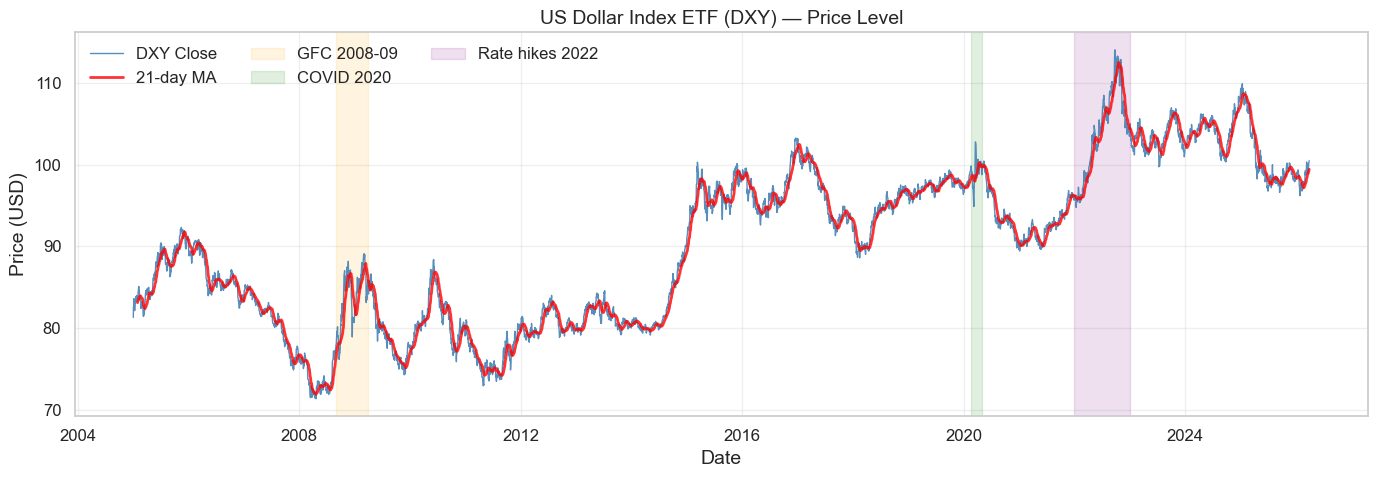

Fig 1 saved.


In [11]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dxy_clean.index, dxy_clean['Close'],
        color='steelblue', lw=1.0, alpha=0.9, label='DXY Close')
ma21 = dxy_clean['Close'].rolling(21).mean()
ax.plot(ma21.index, ma21.values,
        color='red', lw=2, alpha=0.8, label='21-day MA')

for start, end, color, lbl in [
    ('2008-09-01', '2009-03-31', 'orange', 'GFC 2008-09'),
    ('2020-02-20', '2020-04-30', 'green',  'COVID 2020'),
    ('2022-01-01', '2022-12-31', 'purple', 'Rate hikes 2022'),
]:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
               alpha=0.12, color=color, label=lbl)

ax.set_title('US Dollar Index ETF (DXY) — Price Level')
ax.set_ylabel('Price (USD)')
ax.set_xlabel('Date')
ax.legend( ncol=3)
plt.tight_layout()
plt.savefig('../reports/figures/nb01_fig1_price.pdf', bbox_inches='tight')
plt.show()
print("Fig 1 saved.")




### Figure 2 — DXY Daily Log-Returns

**What it shows:** Daily log-returns over the full sample period.
Positive days shaded green, negative days red. Zero line in black.

**Thesis use:** Visually demonstrates heteroscedasticity — volatility clearly
clusters around crisis events. Returns appear mean-reverting around zero,
consistent with a random walk in the mean equation.


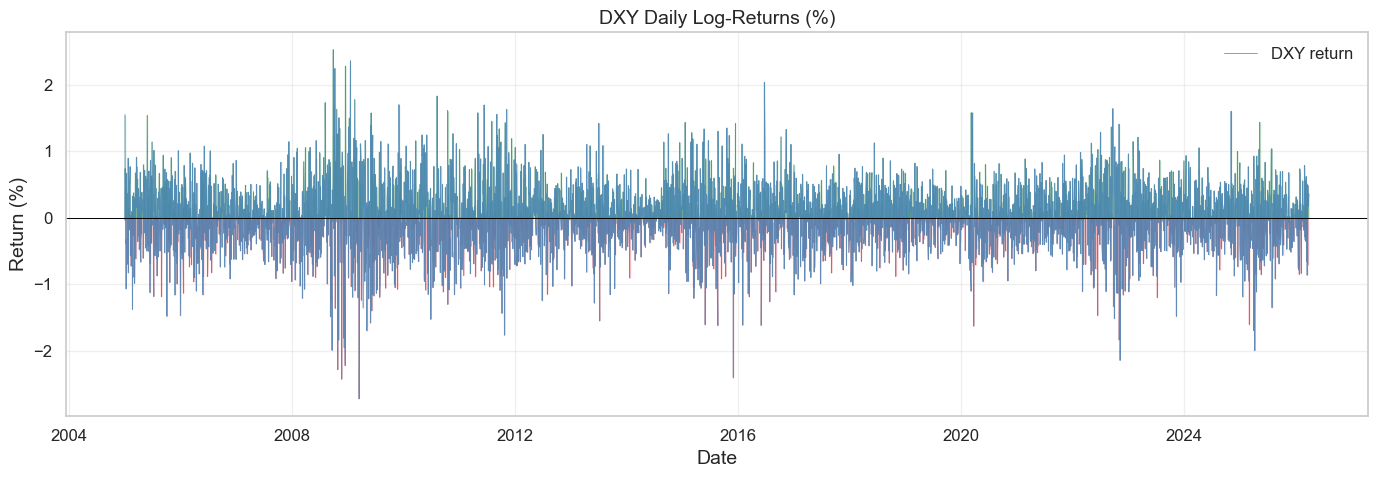

Fig 2 saved.


In [12]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ret.index, ret.values * 100,
        color='steelblue', lw=0.6, alpha=0.85, label='DXY return')
ax.fill_between(ret.index, ret.values * 100, 0,
                where=ret.values > 0, alpha=0.25, color='green')
ax.fill_between(ret.index, ret.values * 100, 0,
                where=ret.values < 0, alpha=0.25, color='red')
ax.axhline(0, color='black', lw=0.7)
ax.set_title('DXY Daily Log-Returns (%)')
ax.set_ylabel('Return (%)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/nb01_fig2_returns.pdf', bbox_inches='tight')
plt.show()
print("Fig 2 saved.")





### Figure 3 — DXY Return Distribution vs Normal and Student-t

**What it shows:** Histogram + KDE of DXY log-returns overlaid with a fitted
Normal distribution and a fitted Student-t distribution.

**Thesis use:** Directly proves that DXY returns have **fat tails** (leptokurtosis)
and are **non-normal**. This justifies:
(1) using Student-t innovations in GARCH instead of Gaussian,
(2) the Jarque-Bera test rejection of normality seen in Section 4.


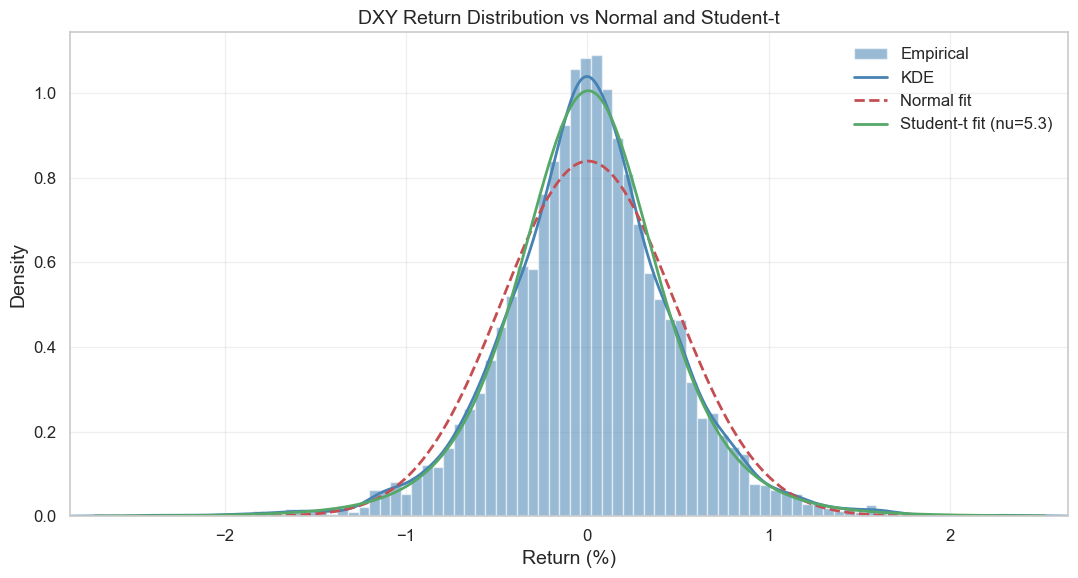

Fig 3 saved.  Student-t fitted df = 5.30


In [13]:
x = np.linspace(ret.min() * 100, ret.max() * 100, 400)
nu, loc_t, scale_t = sp_stats.t.fit(ret * 100)

fig, ax = plt.subplots(figsize=(11, 6))
ax.hist(ret.values * 100, bins=90, density=True,
        color='steelblue', alpha=0.55, edgecolor='white', label='Empirical')
(ret * 100).plot.kde(ax=ax, color='steelblue', lw=2, label='KDE')
ax.plot(x, sp_stats.norm.pdf(x, (ret*100).mean(), (ret*100).std()),
        'r--', lw=2, label='Normal fit')
ax.plot(x, sp_stats.t.pdf(x, nu, loc_t, scale_t),
        'g-', lw=2, label=f'Student-t fit (nu={nu:.1f})')
ax.set_title('DXY Return Distribution vs Normal and Student-t')
ax.set_xlabel('Return (%)')
ax.set_ylabel('Density')
ax.legend()
ax.set_xlim(ret.min() * 100 * 1.05, ret.max() * 100 * 1.05)
plt.tight_layout()
plt.savefig('../reports/figures/nb01_fig3_distribution.pdf', bbox_inches='tight')
plt.show()
print(f"Fig 3 saved.  Student-t fitted df = {nu:.2f}")





### Figure 4 — Squared Returns (Volatility Proxy)

**What it shows:** Squared daily log-returns over the full sample.
Squared returns are a standard proxy for realized variance.

**Thesis use:** The most direct visual proof of **volatility clustering** (ARCH effects).
Large squared returns arrive in bursts — the tranquil periods between crises
show near-zero squared returns. This motivates the GARCH(1,1) specification
instead of a constant variance assumption.


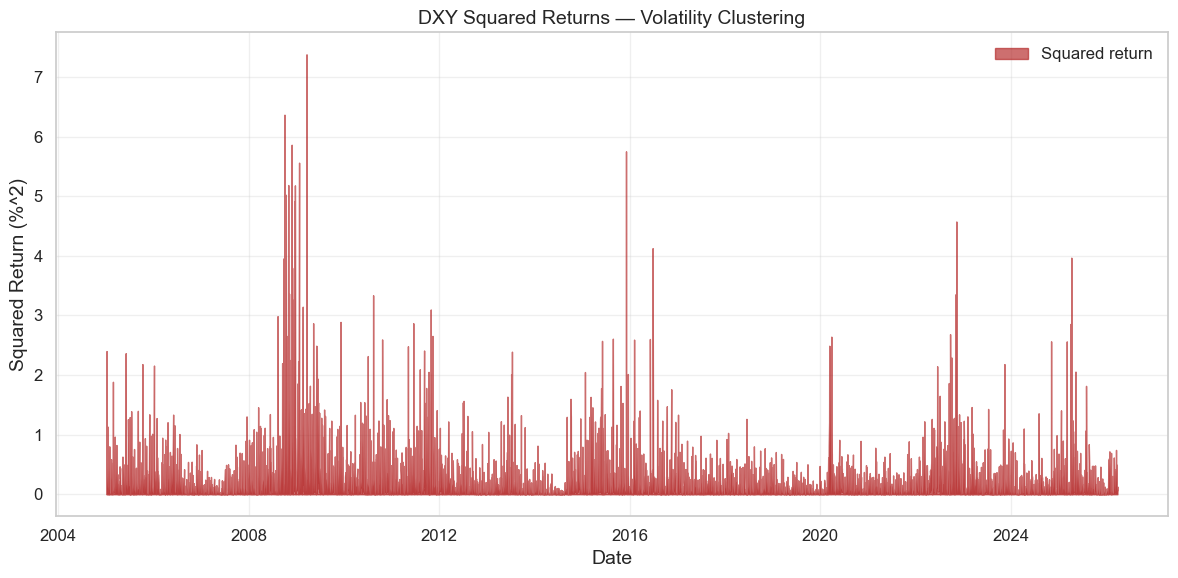

Fig 4 saved.


In [14]:
sq = (ret * 100) ** 2
fig, ax = plt.subplots(figsize=(12, 6))
ax.fill_between(sq.index, sq.values, alpha=0.65, color='firebrick',
                label='Squared return')
ax.set_title('DXY Squared Returns — Volatility Clustering')
ax.set_ylabel('Squared Return (%^2)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/nb01_fig4_squared_returns.pdf', bbox_inches='tight')
plt.show()
print("Fig 4 saved.")





### Figure 5 — Rolling Annualized Volatility

**What it shows:** 21-day (orange) and 63-day (dark red) rolling standard deviation
of returns, annualized by multiplying by sqrt(252).

**Thesis use:** Illustrates **volatility regimes** — the market alternates between
calm periods (vol ~15%) and stress periods (vol >60% during GFC/COVID).
Also used to motivate including rolling volatility features (vol_21, vol_63)
in the Ridge, Lasso, and ML models.


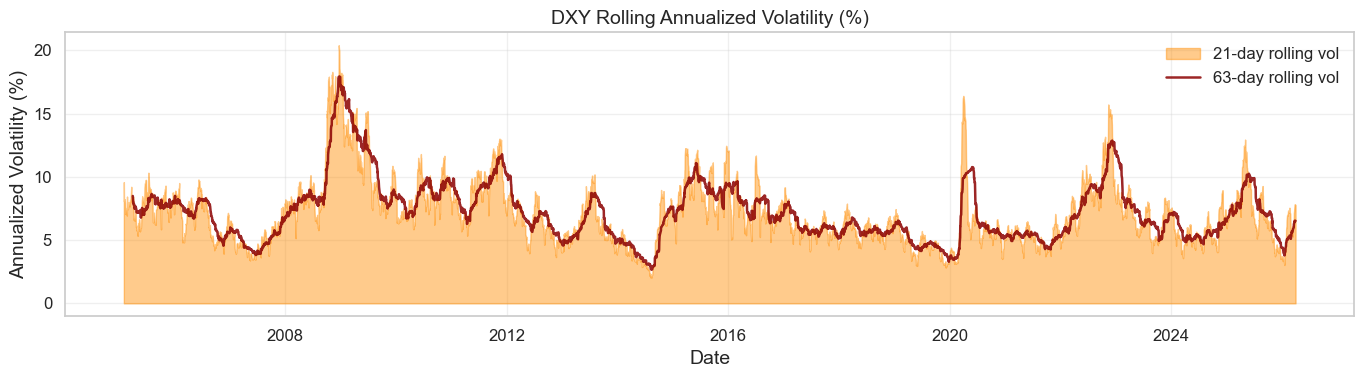

Fig 5 saved.


In [15]:
roll21 = ret.rolling(21).std() * np.sqrt(252) * 100
roll63 = ret.rolling(63).std() * np.sqrt(252) * 100

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(roll21.index, roll21.values, alpha=0.45, color='darkorange',
                label='21-day rolling vol')
ax.plot(roll63.index, roll63.values, color='darkred', lw=1.8, alpha=0.85,
        label='63-day rolling vol')
ax.set_title('DXY Rolling Annualized Volatility (%)')
ax.set_ylabel('Annualized Volatility (%)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/nb01_fig5_rolling_vol.pdf', bbox_inches='tight')
plt.show()
print("Fig 5 saved.")





### Figure 6 — ACF and PACF of DXY Log-Returns

**What it shows:** Autocorrelation Function (top) and Partial Autocorrelation Function
(bottom) of DXY daily log-returns up to lag 40. Blue dashed lines are 95% confidence
bounds under the white noise null.

**Thesis use:** Used to visually select the ARIMA order. Significant spikes suggest
AR or MA components. The absence of large, persistent spikes is consistent with
weak-form EMH — returns are close to a random walk. This chart directly precedes
the formal ADF/KPSS stationarity tests in Section 4.


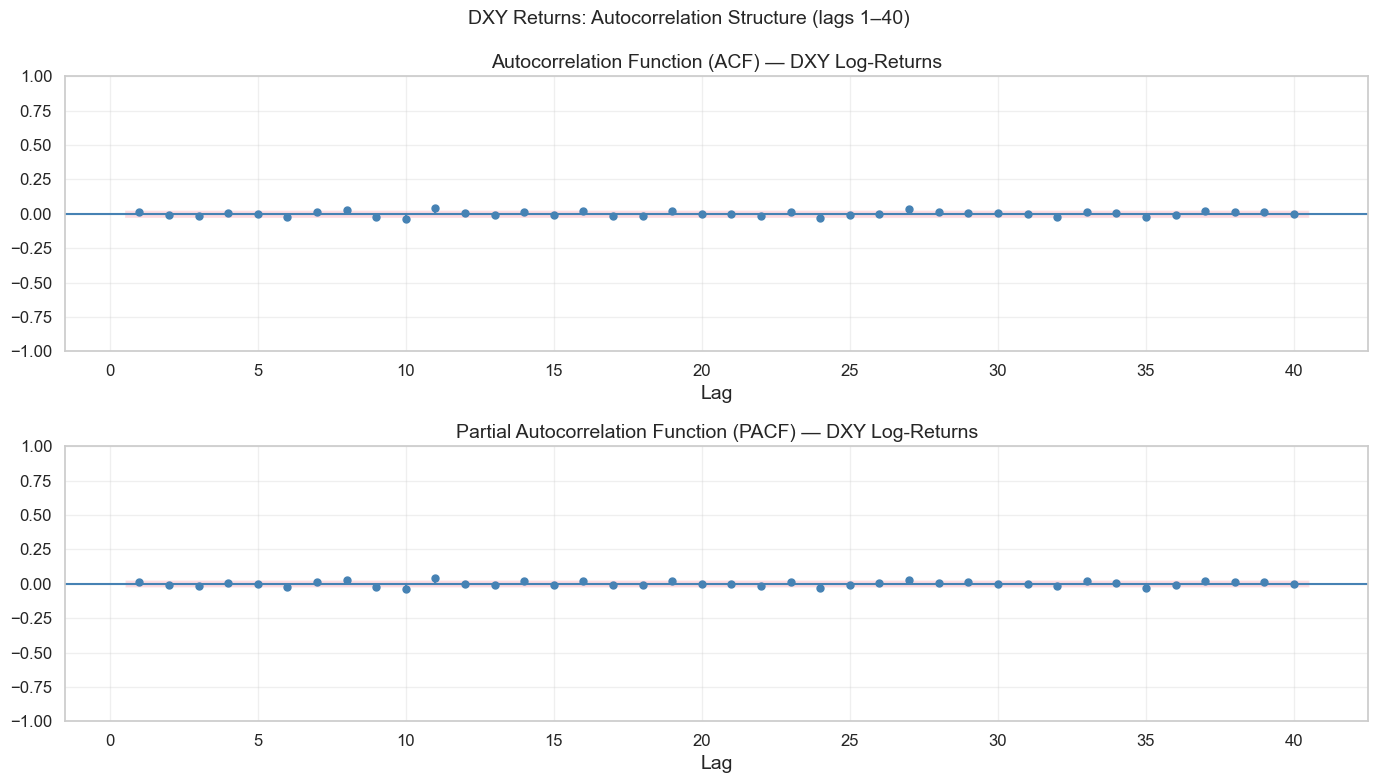

Fig 6 saved.


In [16]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(ret.values, lags=40, ax=axes[0], zero=False, alpha=0.05,
         color='steelblue', vlines_kwargs={'colors': 'steelblue'})
axes[0].set_title('Autocorrelation Function (ACF) — DXY Log-Returns')
axes[0].set_xlabel('Lag')

plot_pacf(ret.values, lags=40, ax=axes[1], zero=False, alpha=0.05, method='ywm',
          color='steelblue', vlines_kwargs={'colors': 'steelblue'})
axes[1].set_title('Partial Autocorrelation Function (PACF) — DXY Log-Returns')
axes[1].set_xlabel('Lag')

plt.suptitle('DXY Returns: Autocorrelation Structure (lags 1–40)')
plt.tight_layout()
plt.savefig('../reports/figures/nb01_fig6_acf_pacf.pdf', bbox_inches='tight')
plt.show()
print("Fig 6 saved.")




### Figure 7 — Full Correlation Matrix (DXY + Cross-Assets)

**What it shows:** Pearson correlation matrix of DXY and all 9 cross-asset
log-returns. The full symmetric matrix is shown (both triangles).

**Thesis use:** Justifies the selection of 9 exogenous variables for the ARIMAX
and linear regression models. Strong negative correlation with DXY (dollar strength)
and positive correlation with S&P 500 and emerging market FX are economically
meaningful and expected.


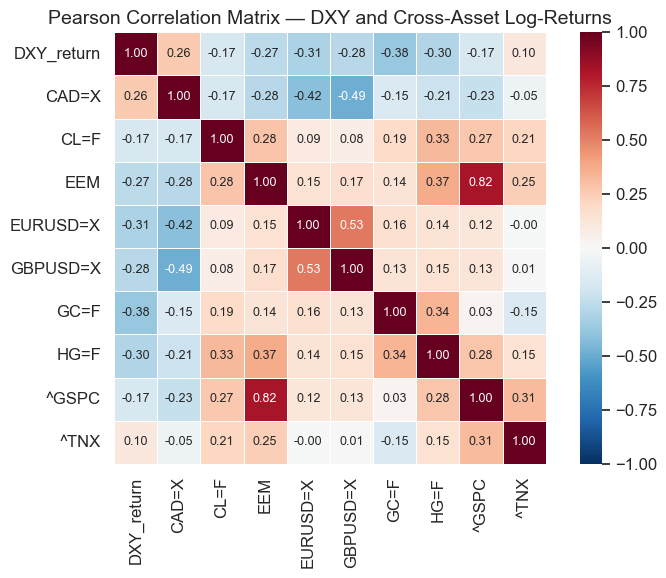

Fig 7 saved.


In [17]:
corr = all_returns.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, square=True, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 9})
ax.set_title('Pearson Correlation Matrix — DXY and Cross-Asset Log-Returns')
plt.tight_layout()
plt.savefig('../reports/figures/nb01_fig7_correlation.pdf', bbox_inches='tight')
plt.show()
print("Fig 7 saved.")




### Figure 8 — Cross-Asset Daily Returns (Small Multiples)

**What it shows:** Daily log-returns for each of the 9 exogenous variables
(DXY, VIX, 10Y Treasury, Oil, Copper, Gold, S&P 500, CNY, JPY).

**Thesis use:** Lets the reader visually compare the behavior of all input features.
Shows which assets share volatility clustering with DXY and which have different
risk profiles — supporting the feature selection rationale.


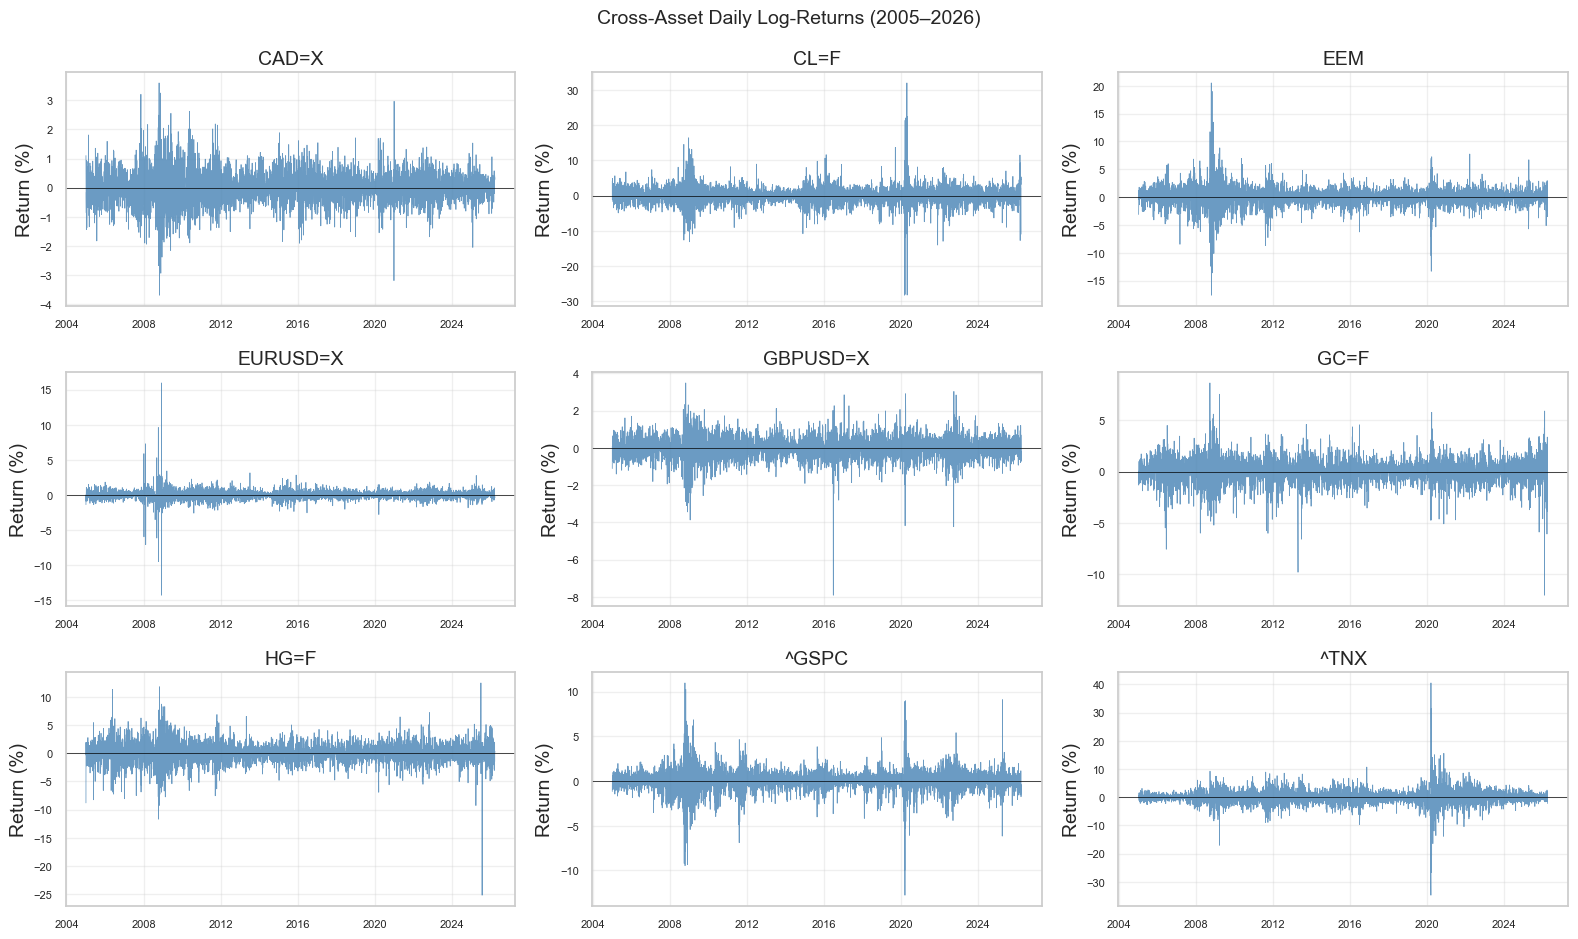

Fig 8 saved.


In [18]:
feat_cols = [c for c in feature_returns.columns if c in all_returns.columns]
n      = len(feat_cols)
ncols  = 3
nrows  = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.2))
axes_flat  = axes.flatten()

for i, col in enumerate(feat_cols):
    ax   = axes_flat[i]
    vals = feature_returns[col].dropna() * 100
    ax.plot(vals.index, vals.values, color='steelblue', lw=0.55, alpha=0.8)
    ax.axhline(0, color='black', lw=0.5)
    ax.set_title(col)
    ax.set_ylabel('Return (%)')
    ax.tick_params(labelsize=8)

for j in range(i + 1, nrows * ncols):
    axes_flat[j].set_visible(False)

plt.suptitle('Cross-Asset Daily Log-Returns (2005–2026)')
plt.tight_layout()
plt.savefig('../reports/figures/nb01_fig8_cross_asset.pdf', bbox_inches='tight')
plt.show()
print("Fig 8 saved.")




### Figure 9 — Rolling 63-Day Correlation: DXY vs Cross-Assets

**What it shows:** 63-day rolling Pearson correlation between DXY returns
and each of the 9 exogenous variables over time.

**Thesis use:** Proves that correlations are **time-varying** and unstable.
A feature that was strongly correlated with DXY in 2008 may have near-zero
correlation in 2015. This motivates why a static linear model (Ridge/Lasso
estimated once on training data) may struggle OOS — and explains why the
DM test fails to reject the random walk.


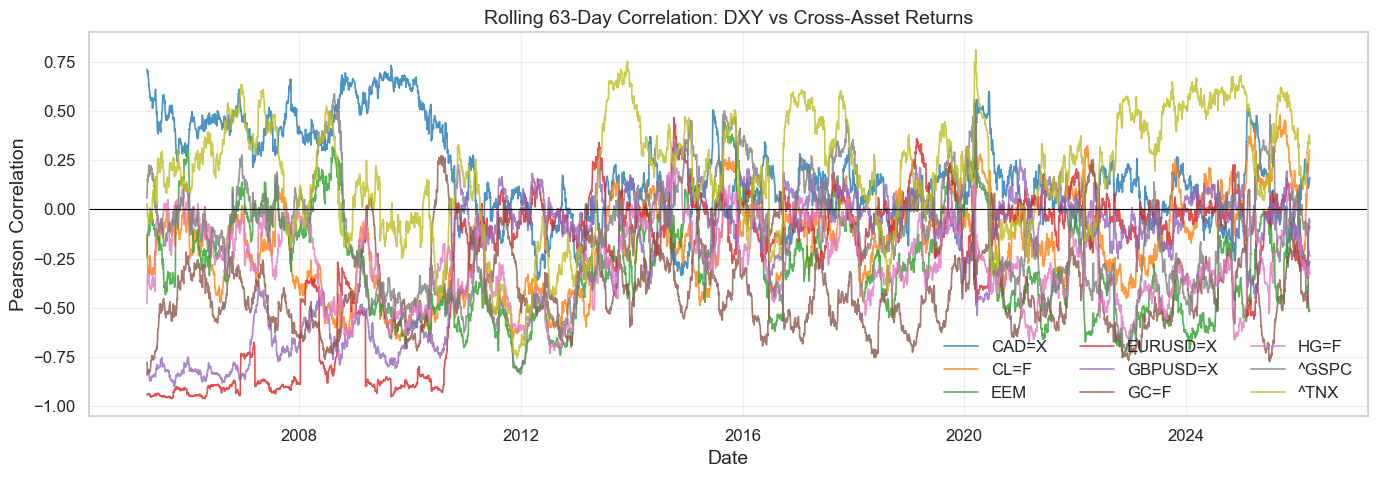

Fig 9 saved.


In [19]:
window   = 63
colors10 = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(14, 5))
for i, col in enumerate(feat_cols):
    if col in all_returns.columns:
        rc = all_returns['DXY_return'].rolling(window).corr(all_returns[col])
        ax.plot(rc.index, rc.values,
                label=col, color=colors10[i % 10], lw=1.2, alpha=0.8)

ax.axhline(0, color='black', lw=0.8)
ax.set_title(f'Rolling {window}-Day Correlation: DXY vs Cross-Asset Returns')
ax.set_ylabel('Pearson Correlation')
ax.set_xlabel('Date')
ax.legend( ncol=3, loc='lower right')
plt.tight_layout()
plt.savefig('../reports/figures/nb01_fig9_rolling_corr.pdf', bbox_inches='tight')
plt.show()
print("Fig 9 saved.")




### Figure 10 — Return Distribution Boxplots (All Assets)

**What it shows:** Side-by-side boxplots of daily log-return distributions for
DXY and all 9 cross-asset instruments.

**Thesis use:** Quick visual comparison of return magnitudes, outliers (dots),
asymmetry (median line position), and tail risk across all assets.
VIX changes (percentage) tend to have extreme outliers; gold and currency
pairs show narrower distributions. Confirms that each asset has a distinct
risk profile — non-trivial information content for the model.


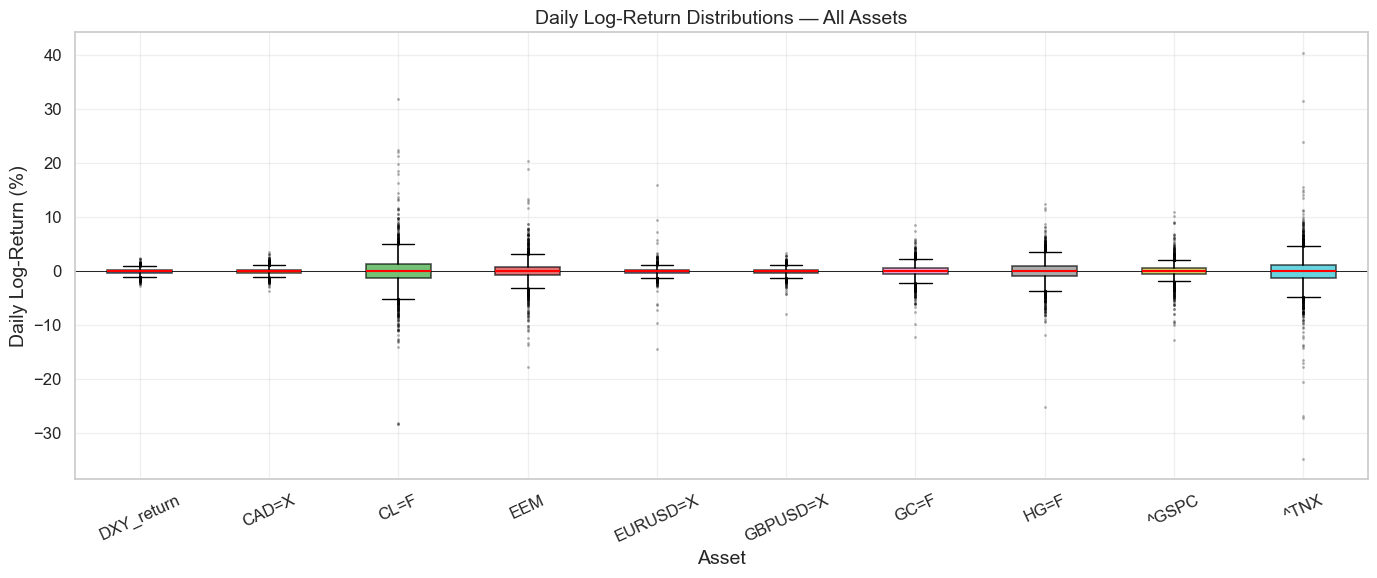

Fig 10 saved.

 All 10 figures saved to ../reports/figures/


In [20]:
bp_data   = [all_returns[c].dropna().values * 100 for c in all_returns.columns]
bp_labels = list(all_returns.columns)
colors10  = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(14, 6))
bp = ax.boxplot(
    bp_data, labels=bp_labels, patch_artist=True,
    medianprops={'color': 'red', 'linewidth': 1.5},
    flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3},
    whiskerprops={'linewidth': 1.2},
    boxprops={'linewidth': 1.2})
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(colors10[i % 10])
    patch.set_alpha(0.65)

ax.axhline(0, color='black', lw=0.6)
ax.set_title('Daily Log-Return Distributions — All Assets')
ax.set_ylabel('Daily Log-Return (%)')
ax.set_xlabel('Asset')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.savefig('../reports/figures/nb01_fig10_boxplots.pdf', bbox_inches='tight')
plt.show()
print("Fig 10 saved.")
print("\n All 10 figures saved to ../reports/figures/")


